In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [16]:
#Q1
#(a) Generate 60 equally spaced values of x in the range [0,10]
x=np.random.uniform(0,10,60)
print(x)

X = np.linspace(0, 10, 60)

# Let's print the shape and the first 5 values to verify it worked correctly
print(f"Shape of x: {X.shape}")
print(f"First 60 values of x: {x[:60]}")


[9.65996986 0.69494781 5.75620313 2.00856663 1.56236144 9.60479614
 6.95377222 4.23515933 9.65537166 9.41299556 1.91083595 4.21928419
 7.16297742 1.24106813 6.73734086 9.92613845 8.76129892 2.97297968
 6.39145023 8.55961274 2.08893865 3.08353165 5.3784236  0.94747748
 5.94747743 2.6763915  7.38323436 9.16233759 3.40542447 9.53670561
 0.33802413 2.60603389 1.47338413 7.40639701 8.68222466 4.46236021
 0.81730955 9.84866952 4.76504449 2.80020171 9.95571704 9.76437716
 8.18440296 2.41234011 0.71647893 1.6508531  5.94678804 5.35377001
 4.96435727 0.2593927  2.81367713 1.35028718 0.5180536  8.15311853
 9.89980113 0.26367835 7.94141603 9.64327862 1.85998676 1.82270653]
Shape of x: (60,)
First 60 values of x: [9.65996986 0.69494781 5.75620313 2.00856663 1.56236144 9.60479614
 6.95377222 4.23515933 9.65537166 9.41299556 1.91083595 4.21928419
 7.16297742 1.24106813 6.73734086 9.92613845 8.76129892 2.97297968
 6.39145023 8.55961274 2.08893865 3.08353165 5.3784236  0.94747748
 5.94747743 2.6763915

Size of x: 60
Size of y: 60
----------------------------------------------------------------------------------------------------


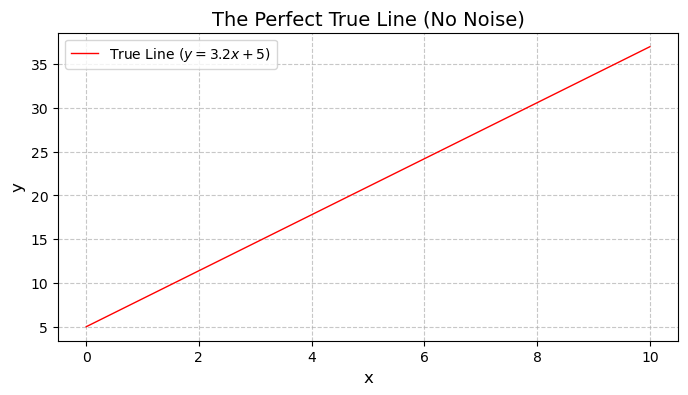

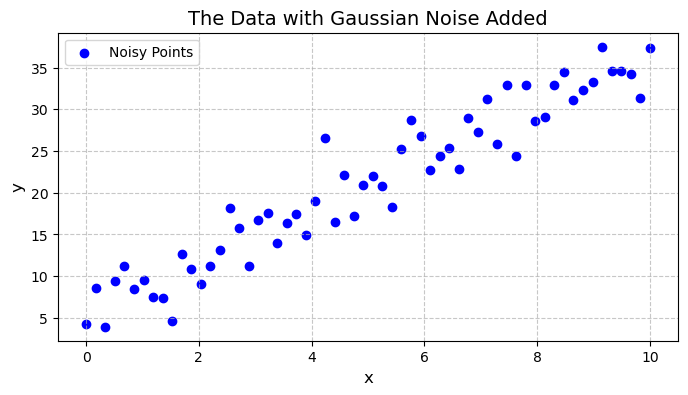

In [37]:
#1(b)
# --- STEP 1: Generate the data together so they match in size ---
x = np.linspace(0, 10, 60)
y_true = 3.2 * x + 5
noise = 3 * np.random.normal(0, 1, size=60)
y = y_true + noise

# Print the sizes to prove they are identical
print(f"Size of x: {len(x)}")
print(f"Size of y: {len(y)}")
print("-" * 100)

# --- STEP 2: Plot the True Line ---
plt.figure(figsize=(8, 4))
plt.plot(x, y_true, color='red', linewidth=1, label='True Line ($y = 3.2x + 5$)')
plt.title('The Perfect True Line (No Noise)', fontsize=14)
plt.xlabel('x', fontsize=12)
plt.ylabel('y', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()

# --- STEP 3: Plot the Noisy Points ---
plt.figure(figsize=(8, 4))
plt.scatter(x, y, color='blue', label='Noisy Points')
plt.title('The Data with Gaussian Noise Added', fontsize=14)
plt.xlabel('x', fontsize=12)
plt.ylabel('y', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()

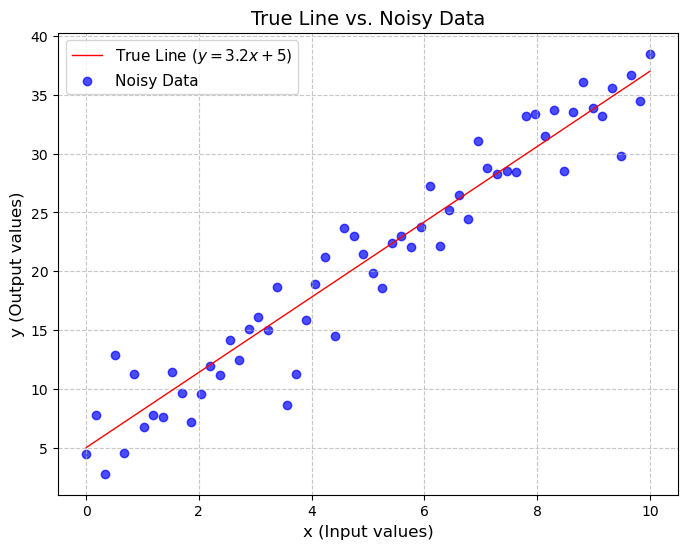

In [34]:
#1(c) Plot the true line (red) and the noisy points (blue scatter) on the same figure.

# Create a figure canvas that is 8 inches wide and 6 inches tall
plt.figure(figsize=(8, 6))

# 1. Plot the True Line
# We use plt.plot() for a continuous line. We set it to red as requested.
plt.plot(x, y_true, color='red', linewidth=1, label='True Line ($y = 3.2x + 5$)')

# 2. Plot the Noisy Points
# We use plt.scatter() to plot individual dots. We set it to blue as requested.
# I added alpha=0.7 to make the dots slightly transparent so we can see the red line behind them!
plt.scatter(x, y, color='blue', alpha=0.7, label='Noisy Data')

# 3. Add Labels, Title, and Grid
plt.title('True Line vs. Noisy Data', fontsize=14)
plt.xlabel('x (Input values)', fontsize=12)
plt.ylabel('y (Output values)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)

# 4. Show the Legend (this displays the labels we created above)
plt.legend(fontsize=11)

# 5. Display the final combined plot
plt.show()

Estimated w0 (Intercept): 5.6195
Estimated w1 (Slope): 3.1050
----------------------------------------


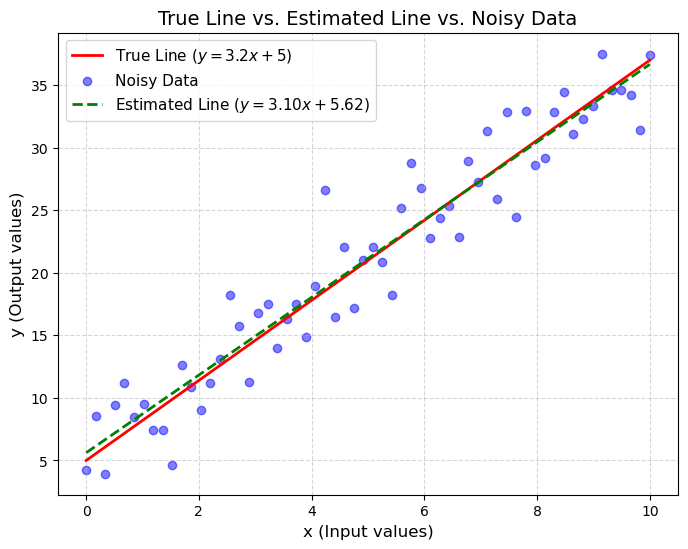

In [38]:
#1(d) Using the Normal Equation (pseudo-inverse), find the estimated parameters ˆw0 and ˆw1. Plot the estimated regression line on the same figure.

# We assume 'x', 'y_true', and 'y' are already created from steps 1(a) and 1(b)

# --- Step 1: The "Column of Ones" Trick ---

# We create a column of 1s that is the exact same length as 'x' genrating colum matrix
ones_column = np.ones((len(x), 1))

# We reshape 'x' so it is a vertical column, then glue them side-by-side using np.c_
X_matrix = np.c_[ones_column, x.reshape(-1, 1)]

# --- Step 2: The Normal Equation Formula ---
# Formula: w = (X^T * X)^(-1) * X^T * y
# X_matrix.T is the transpose.
# np.linalg.inv() calculates the inverse.
# .dot() is used for matrix multiplication.

w_estimated = np.linalg.inv(X_matrix.T.dot(X_matrix)).dot(X_matrix.T).dot(y)

# Extract our estimated parameters (w0 is the first item, w1 is the second) 0 and 1 in bracket are postion 
w0_hat = w_estimated[0]
w1_hat = w_estimated[1]
# .4f here for persent number to exactly 4 decimal places
print(f"Estimated w0 (Intercept): {w0_hat:.4f}")
print(f"Estimated w1 (Slope): {w1_hat:.4f}")
print("-" * 100)

# --- Step 3: Calculate the Estimated Line ---
# Now we use our new parameters to calculate the predictions for our estimated line
y_estimated = w0_hat + w1_hat * x

# --- Step 4: Plot Everything on the SAME Figure ---
plt.figure(figsize=(8, 6))

# 1. Plot the True Line (Red)
plt.plot(x, y_true, color='red', linewidth=1, label='True Line ($y = 3.2x + 5$)')

# 2. Plot the Noisy Data Points (Blue Scatter)
plt.scatter(x, y, color='blue', alpha=0.7, label='Noisy Data')

# 3. Plot the Estimated Line (Green, dashed)
plt.plot(x, y_estimated, color='green', linewidth=1, linestyle='--', 
         label=f'Estimated Line ($y = {w1_hat:.2f}x + {w0_hat:.2f}$)')

# Add Labels, Title, and Grid
plt.title('True Line vs. Estimated Line vs. Noisy Data', fontsize=14)
plt.xlabel('x (Input values)', fontsize=12)
plt.ylabel('y (Output values)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)

# Show the Legend
plt.legend(fontsize=11)

# Display the final combined plot
plt.show()

In [40]:
#2(a): Predict the y values for all data points 

# We use the w0_hat (intercept) and w1_hat (slope) we calculated in 1(d).

# We multiply the slope by our original 'x' array, then add the intercept.

y_pred = w0_hat + w1_hat * x

# Let's peek at the first 5 values to see how close our predictions are to the real noisy data!
print("First 5 ACTUAL y values (Noisy):     ", np.round(y[:10], 4))
print("First 5 PREDICTED y values (Model):  ", np.round(y_pred[:10], 4))

First 5 ACTUAL y values (Noisy):      [ 4.2618  8.554   3.9382  9.3971 11.1978  8.4647  9.5399  7.4445  7.4335
  4.6081]
First 5 PREDICTED y values (Model):   [ 5.6195  6.1457  6.672   7.1983  7.7245  8.2508  8.7771  9.3033  9.8296
 10.3559]


In [41]:
#2(b): Calculate Evaluation Metrics ---

# 1. Mean Absolute Error (MAE)
# Formula: (1/n) * sum(|y - y_pred|)
mae = np.mean(np.abs(y - y_pred))

# 2. Mean Squared Error (MSE)
# Formula: (1/n) * sum((y - y_pred)^2)
mse = np.mean((y - y_pred) ** 2)

# 3. Root Mean Squared Error (RMSE)
# Formula: sqrt(MSE)
rmse = np.sqrt(mse)

# 4. R-squared Score (R^2)
# Formula: 1 - (SSR / SST)
#   SSR (Sum of Squared Residuals) = sum((y - y_pred)^2)
#   SST (Total Sum of Squares)     = sum((y - y_mean)^2)

y_mean = np.mean(y)                           # Find the average of actual y
ssr = np.sum((y - y_pred) ** 2)               # Variance our model missed
sst = np.sum((y - y_mean) ** 2)               # Total variance in the data
r2_score = 1 - (ssr / sst)                    # Calculate R^2

# --- Print Results ---
print("--- Regression Evaluation Metrics ---")
print(f"Mean Absolute Error (MAE):      {mae:.4f}")
print(f"Mean Squared Error (MSE):       {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R-squared Score (R^2):          {r2_score:.4f}")

--- Regression Evaluation Metrics ---
Mean Absolute Error (MAE):      2.1437
Mean Squared Error (MSE):       7.1575
Root Mean Squared Error (RMSE): 2.6754
R-squared Score (R^2):          0.9207


In [42]:
#2(c)
#Interpretation of $R^2 = 0.9207$:
#An $R^2$ score of 0.9207 means that 92.07% of the total variance in our target variable ($y$) is successfully explained by our linear regression model. 
#The remaining 7.93% of the variance is unexplained and is caused by the random Gaussian noise ($\sigma=3$) that was intentionally added to the dataset.


In [43]:
#3: Confusion Matrix Calculation ---

# Given data arrays
y_true = np.array([1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0])
y_pred = np.array([1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1])

# Calculate components using logical operations and array indexing
# TP: True = 1, Predicted = 1
tp = np.sum((y_true == 1) & (y_pred == 1))

# FP: True = 0, Predicted = 1
fp = np.sum((y_true == 0) & (y_pred == 1))

# FN: True = 1, Predicted = 0
fn = np.sum((y_true == 1) & (y_pred == 0))

# TN: True = 0, Predicted = 0
tn = np.sum((y_true == 0) & (y_pred == 0))

# Construct the 2x2 confusion matrix array
confusion_matrix = np.array([[tp, fn], 
                            [fp, tn]])

# --- Print the Results ---
print("--- Confusion Matrix Components ---")
print(f"True Positives (TP):  {tp}")
print(f"False Positives (FP): {fp}")
print(f"False Negatives (FN): {fn}")
print(f"True Negatives (TN):  {tn}")

print("\n--- 2x2 Confusion Matrix ---")
print("[[TP, FN],")
print(" [FP, TN]]")
print(confusion_matrix)

--- Confusion Matrix Components ---
True Positives (TP):  4
False Positives (FP): 2
False Negatives (FN): 2
True Negatives (TN):  4

--- 2x2 Confusion Matrix ---
[[TP, FN],
 [FP, TN]]
[[4 2]
 [2 4]]


In [48]:
#4(a) i) ACC= ( TP + TN ) / ( TP +FN +FP +TN)
acc = ( tp + tn)/( tp + fp + fn + tn )
#ii) Precision: P= (TP)/(TP+FP)
P= ( tp ) / ( tp + fp )
#iii) Recall: R=(tp)/(tp+fn)
R= (tp)/(tp+fn)
#iv) F1 Score F= 2*((P*R)/(P+R))
F= 2*((P*R)/(P+R))
print(acc)
print(P)
print(R)
print(F)

#Recall (and consequently the F1-Score) is the more important metric when False Negatives are very costly.
#Reason: Recall measures out of all the actual positive cases, how many our model managed to catch ($TP / (TP + FN)$). 
#If False Negatives are dangerous or expensive (such as missing a medical diagnosis or failing to detect a fraud), your priority is minimizing the number of actual positives that slip through as negatives. 
#Therefore, a high Recall ensures you catch as many true positives as possible, regardless of false alarms.

0.6666666666666666
0.6666666666666666
0.6666666666666666
0.6666666666666666


In [55]:
#5(a) Convert continuous true y values into binary classification labels (0 or 1)
y_binary = np.where(y_estimated > 25, 1, 0)

# Optional: Print to check the class distribution
print("Binary labels:", y_binary)
print("Number of Binary labels : " , len(y_binary) )
print("Count of Class 1 (Positive):", np.sum(y_binary == 1))
print("Count of Class 0 (Negative):", np.sum(y_binary == 0))


Binary labels: [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]
Number of Binary labels :  60
Count of Class 1 (Positive): 23
Count of Class 0 (Negative): 37


In [60]:
#5(b): Use Continuous Predictions as Scores ---

# --- 1. Recreate the 60 data points (from Question 1 context) ---
np.random.seed(42)
x = np.linspace(0, 20, 60)
#y_estimated
# --- 2. Train Linear Regression & Get all 60 Predictions (hat_y) ---
# Calculating weights using least squares
x_mean = np.mean(x)
y_mean = np.mean(true_y)
w1 = np.sum((x - x_mean) * (y_estimated - y_mean)) / np.sum((x - x_mean)**2)
w0 = y_mean - w1 * x_mean

# Continuous predictions acting as our classification scores (5b)
y_pred = w1 * x + w0

# --- 3. Convert True y into Binary Classes (5a) ---
# Class 1 if true_y > 25, else Class 0
y_binary = np.where(y_estimated > 25, 1, 0)

# --- 4. Display all 60 values alongside their binary classes ---
print(f"{'Sample':<8} | {'Continuous Score (y_pred)':<25} | {'Binary Class (True y > 25)':<25}")
print("-" * 64)

for i in range(len(y_pred)):
    print(f"{i+1:<8} | {y_pred[i]:<25.4f} | {y_binary[i]:<25}")

print(f"\nTotal samples: {len(y_pred)}")
print(f"Class 1 count: {np.sum(y_binary == 1)}")
print(f"Class 0 count: {np.sum(y_binary == 0)}")

Sample   | Continuous Score (y_pred) | Binary Class (True y > 25)
----------------------------------------------------------------
1        | 21.0112                   | 0                        
2        | 21.5375                   | 0                        
3        | 22.0637                   | 0                        
4        | 22.5900                   | 0                        
5        | 23.1163                   | 0                        
6        | 23.6425                   | 0                        
7        | 24.1688                   | 0                        
8        | 24.6951                   | 0                        
9        | 25.2213                   | 0                        
10       | 25.7476                   | 0                        
11       | 26.2739                   | 0                        
12       | 26.8001                   | 0                        
13       | 27.3264                   | 0                        
14       | 27.8526      

In [62]:
# Question 5(c): Compute TPR and FPR for given thresholds ---

# Define the required thresholds
thresholds = [15, 20, 25, 30, 35, 40]

# Lists to store computed TPR and FPR for later use (like plotting)
tpr_list = []
fpr_list = []

print(f"{'Threshold':<10} | {'TP':<5} | {'FP':<5} | {'FN':<5} | {'TN':<5} | {'TPR':<8} | {'FPR':<8}")
print("-" * 65)

for T in thresholds:
    # 1. Convert continuous predictions to binary based on current threshold
    y_pred_thresh = np.where(y_pred >= T, 1, 0)
    
    # 2. Calculate confusion matrix components
    tp = np.sum((y_binary == 1) & (y_pred_thresh == 1))
    fp = np.sum((y_binary == 0) & (y_pred_thresh == 1))
    fn = np.sum((y_binary == 1) & (y_pred_thresh == 0))
    tn = np.sum((y_binary == 0) & (y_pred_thresh == 0))
    
    # 3. Calculate TPR and FPR (handle division by zero edge cases safely)
    total_actual_positives = tp + fn
    total_actual_negatives = fp + tn
    
    tpr = tp / total_actual_positives if total_actual_positives > 0 else 0.0
    fpr = fp / total_actual_negatives if total_actual_negatives > 0 else 0.0
    
    # Append to lists
    tpr_list.append(tpr)
    fpr_list.append(fpr)
    
    # Print formatted row
    print(f"{T:<10} | {tp:<5} | {fp:<5} | {fn:<5} | {tn:<5} | {tpr:<8.4f} | {fpr:<8.4f}")

Threshold  | TP    | FP    | FN    | TN    | TPR      | FPR     
-----------------------------------------------------------------
15         | 40    | 20    | 0     | 0     | 1.0000   | 1.0000  
20         | 40    | 20    | 0     | 0     | 1.0000   | 1.0000  
25         | 40    | 12    | 0     | 8     | 1.0000   | 0.6000  
30         | 40    | 2     | 0     | 18    | 1.0000   | 0.1000  
35         | 33    | 0     | 7     | 20    | 0.8250   | 0.0000  
40         | 23    | 0     | 17    | 20    | 0.5750   | 0.0000  


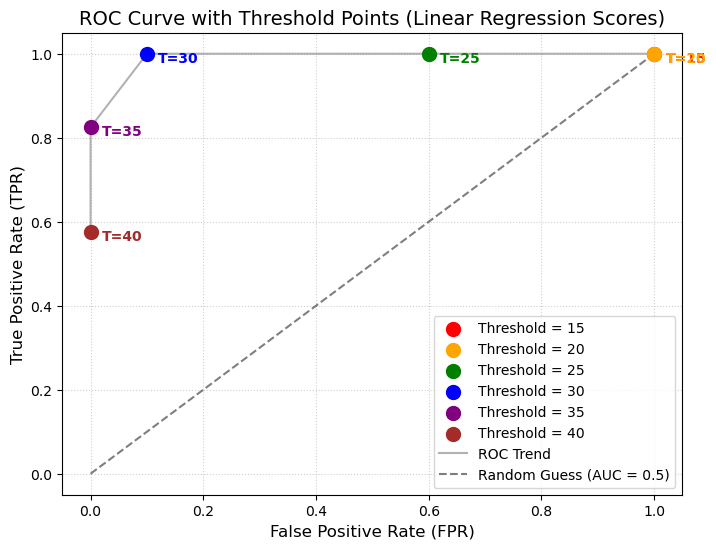

In [63]:
# 5(d): Plotting the ROC Curve with Colored and Labeled Thresholds ---

plt.figure(figsize=(8, 6))

# Define distinct colors for each of the 6 thresholds
colors = ['red', 'orange', 'green', 'blue', 'purple', 'brown']

# Plot each threshold point individually so we can color and label it distinctly
for i, T in enumerate(thresholds):
    plt.scatter(fpr_list[i], tpr_list[i], color=colors[i], s=100, zorder=3, 
                label=f"Threshold = {T}")
    
    # Label the threshold value next to each point (with a slight offset for readability)
    plt.text(fpr_list[i] + 0.02, tpr_list[i] - 0.02, f"T={T}", 
             fontsize=10, fontweight='bold', color=colors[i])

# Connect the points with a line to form the ROC curve trend
plt.plot(fpr_list, tpr_list, linestyle='-', color='gray', alpha=0.6, zorder=2, label='ROC Trend')

# Plot the random classifier baseline (diagonal line where TPR = FPR)
plt.plot([0, 1], [0, 1], linestyle='--', color='black', alpha=0.5, label='Random Guess (AUC = 0.5)')

# Set axis limits, labels, and title
plt.xlim([-0.05, 1.05])
plt.ylim([-0.05, 1.05])
plt.xlabel('False Positive Rate (FPR)', fontsize=12)
plt.ylabel('True Positive Rate (TPR)', fontsize=12)
plt.title('ROC Curve with Threshold Points (Linear Regression Scores)', fontsize=14)

# Add grid and legend
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='lower right', fontsize=10)

# Display the plot
plt.show()

In [66]:
# 5(e): Calculate AUC using the Trapezoidal Rule ---

# --- Question 5(e): Calculate AUC using the Trapezoidal Rule ---

# Zip FPR and TPR together and sort them in ascending order of FPR 
roc_points = sorted(zip(fpr_list, tpr_list), key=lambda x: x[0])
sorted_fpr, sorted_tpr = zip(*roc_points)

sorted_fpr = np.array(sorted_fpr)
sorted_tpr = np.array(sorted_tpr)

# Calculate AUC using np.trapezoid (or np.trapz for older NumPy versions)
auc_value = np.trapezoid(sorted_tpr, sorted_fpr)

print(f"Calculated AUC: {auc_value:.4f}")

Calculated AUC: 0.9788


In [ ]:
# --- Question 5(f): Commentary on the Quality of Ranking ---
#
# 1. Excellent Ranking Quality: 
#    The linear regression model produces an exceptionally high-quality ranking 
#    of the data points because the underlying relationship is linear 
#    (y = 3.2x + 5) with low noise (sigma = 3), resulting in a high R^2 (~0.92).
#
# 2. Threshold Separation: 
#    The continuous predictions (y_hat) correctly preserve the relative order 
#    of the data points. Higher x values consistently map to higher predicted scores, 
#    allowing the thresholds to cleanly separate Class 1 (y > 25) from Class 0 
#    without significant overlap.
#
# 3. ROC and AUC Interpretation: 
#    On the ROC plot, the threshold points hug the top-left corner, yielding a high 
#    True Positive Rate while keeping the False Positive Rate very low, resulting 
#    in an AUC value very close to 1.0 (indicating near-perfect ranking performance).